---

# University of Liverpool

## COMP634 - Applied AI

---

Use this first cell to import the necessary libraries.

In [22]:
import zipfile
import os
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import math
import matplotlib.pyplot as plt
import pandas as pd

from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, top_k_accuracy_score
from torchvision.datasets import ImageFolder
from torch.utils.data import Subset, DataLoader,WeightedRandomSampler
from torchvision import transforms
from tqdm import tqdm
from torchvision.models import resnet18
from IPython.display import display



zip_path = "/content/assignment2_dataset.zip"
extract_path = "dataset_root"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted to:", extract_path)


Extracted to: dataset_root


In [23]:

# Reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

root = "dataset_root/dataset"   # adjust if your folder name differs
transform = transforms.ToTensor()
ds = ImageFolder(root=root, transform=transform)

# Build a base dataset that returns PIL images so we can apply split specific transforms later
base_ds = ImageFolder(root=root)
classes = base_ds.classes
num_classes = len(classes)
print("Classes:", classes)
print("Number of images:", len(base_ds))

# Labels for stratification
y = [base_ds.samples[i][1] for i in range(len(base_ds))]
idx_all = np.arange(len(base_ds))

# 80 10 10 stratified split
idx_train, idx_tmp, y_train, y_tmp = train_test_split(
    idx_all, y, test_size=0.20, stratify=y, random_state=seed
)
idx_val, idx_test, y_val, y_test = train_test_split(
    idx_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=seed
)

print(f"Train size: {len(idx_train)}  Val size: {len(idx_val)}  Test size: {len(idx_test)}")

# Transforms
train_tf = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([transforms.RandomRotation(10)], p=0.25),
    transforms.RandomApply([transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1)], p=0.25),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_tf = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Small helper to apply a transform on top of a Subset
class TransformSubset(Subset):
    def __init__(self, dataset, indices, transform=None):
        super().__init__(dataset, indices)
        self.transform = transform

    def __getitem__(self, idx):
        img, label = super().__getitem__(idx)
        if self.transform is not None:
            img = self.transform(img)
        return img, label

# Build split datasets
train_ds = TransformSubset(base_ds, idx_train, transform=train_tf)
val_ds   = TransformSubset(base_ds, idx_val,   transform=eval_tf)
test_ds  = TransformSubset(base_ds, idx_test,  transform=eval_tf)

# Dataloaders
batch_size = 64
num_workers = 2

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=num_workers, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

# Inspecting class distribution
def describe_split(indices, name):
    cnt = Counter([base_ds.samples[i][1] for i in indices])
    total = len(indices)
    print(f"\n{name} distribution:")
    for c in range(num_classes):
        print(f"  {classes[c]:20s}  count={cnt[c]:4d}  pct={100.0*cnt[c]/total:5.2f}")

describe_split(idx_train, "Train")
describe_split(idx_val,   "Val")
describe_split(idx_test,  "Test")

# Compute class weights from train split only
train_counts = Counter([base_ds.samples[i][1] for i in idx_train])
counts_tensor = torch.tensor([train_counts[c] for c in range(num_classes)], dtype=torch.float32)
class_weights = 1.0 / counts_tensor
class_weights = class_weights / class_weights.sum() * num_classes   # normalize to mean weight 1

print("\nClass counts:", counts_tensor.tolist())
print("Class weights:", class_weights.tolist())

# setting up a weighted CrossEntropyLoss
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = torch.nn.CrossEntropyLoss(weight=class_weights.to(device))


Classes: ['altar', 'apse', 'bell_tower', 'column', 'dome(inner)', 'dome(outer)', 'flying_buttress', 'gargoyle', 'stained_glass', 'vault']
Number of images: 11534
Train size: 9227  Val size: 1153  Test size: 1154

Train distribution:
  altar                 count= 774  pct= 8.39
  apse                  count= 444  pct= 4.81
  bell_tower            count= 982  pct=10.64
  column                count=1699  pct=18.41
  dome(inner)           count= 526  pct= 5.70
  dome(outer)           count=1054  pct=11.42
  flying_buttress       count= 380  pct= 4.12
  gargoyle              count=1442  pct=15.63
  stained_glass         count= 918  pct= 9.95
  vault                 count=1008  pct=10.92

Val distribution:
  altar                 count=  97  pct= 8.41
  apse                  count=  56  pct= 4.86
  bell_tower            count= 122  pct=10.58
  column                count= 212  pct=18.39
  dome(inner)           count=  66  pct= 5.72
  dome(outer)           count= 131  pct=11.36
  flying_but

In [24]:


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# class weights
class_weights = torch.tensor(
    [0.96363134, 1.67984378, 0.75952208, 0.43899390, 1.41796708,
     0.70763820, 1.96276498, 0.51723349, 0.81247342, 0.73993123],
    dtype=torch.float32, device=device
)

# Augmentations
train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1)], p=0.3),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])  # simple symmetric norm
])

eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

# Recreating datasets using indices
full_ds = ImageFolder(root="dataset_root/dataset", transform=None)
train_ds = torch.utils.data.Subset(ImageFolder(root="dataset_root/dataset", transform=train_tf), indices=idx_train)
val_ds   = torch.utils.data.Subset(ImageFolder(root="dataset_root/dataset", transform=eval_tf),  indices=idx_val)
test_ds  = torch.utils.data.Subset(ImageFolder(root="dataset_root/dataset", transform=eval_tf),  indices=idx_test)

batch_size = 128

#plain shuffling
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)




---

# 2. **Neural Networks**

Here, you need to:

1.	propose your own Convolutional Neural Network (CNN) to tackle the problem, aiming to make it as efficient (in terms of trainable parameters) as possible;
2.	define at least one existing CNN (such as AlexNet, VGG, ResNet, DenseNet, etc) to tackle the problem;
3.	define the necessary components to train the networks (that is, loss function, optimizers, etc);
4.	train your proposed architecture from scratch using your training set;
5.	train the existing architecture using at least 2 different strategies (i.e., trained from scratch, fine-tuning, feature extractor, etc);
6.	for all training procedures, separately plot the loss and accuracy with respect to the epoch/iteration.



In [25]:
#Creating a custom CNN model

class DWConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, use_se=False, se_ratio=0.25):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, kernel_size=3, stride=stride, padding=1, groups=in_ch, bias=False)
        self.dw_bn = nn.BatchNorm2d(in_ch)
        self.pw = nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False)
        self.pw_bn = nn.BatchNorm2d(out_ch)
        self.act = nn.GELU()
        self.use_se = use_se
        if use_se:
            hidden = max(8, int(in_ch * se_ratio))
            self.se = nn.Sequential(
                nn.AdaptiveAvgPool2d(1),
                nn.Conv2d(out_ch, hidden, 1),
                nn.GELU(),
                nn.Conv2d(hidden, out_ch, 1),
                nn.Sigmoid()
            )
    def forward(self, x):
        x = self.dw_bn(self.dw(x))
        x = self.act(x)
        x = self.pw_bn(self.pw(x))
        if self.use_se:
            x = x * self.se(x)
        return self.act(x)

class TinyDSCNN(nn.Module):
    def __init__(self, num_classes=10, se=False, drop_p=0.2):
        super().__init__()
        # stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.GELU()
        )
        # stages (downsample by stride 2)
        self.stage1 = nn.Sequential(
            DWConvBlock(32, 64, stride=2, use_se=se),
            DWConvBlock(64, 64, use_se=se),
        )
        self.stage2 = nn.Sequential(
            DWConvBlock(64, 128, stride=2, use_se=se),
            DWConvBlock(128,128, use_se=se),
        )
        self.stage3 = nn.Sequential(
            DWConvBlock(128,192, stride=2, use_se=se),
            DWConvBlock(192,192, use_se=se),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(p=drop_p),
            nn.Linear(192, num_classes)
        )
    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        return self.head(x)

model = TinyDSCNN(num_classes=10, se=True, drop_p=0.2).to(device)


In [26]:

criterion = nn.CrossEntropyLoss(weight=class_weights)

lr = 3e-3
epochs = 18

optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)

# OneCycle:steps_per_epoch
steps_per_epoch = len(train_loader)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=lr, epochs=epochs, steps_per_epoch=steps_per_epoch,
    pct_start=0.3, anneal_strategy='cos', div_factor=10.0, final_div_factor=1e4
)

scaler = torch.cuda.amp.GradScaler(enabled=(device.type=='cuda'))


/tmp/ipython-input-2678713934.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type=='cuda'))


In [27]:

def accuracy(logits, targets):
    return (logits.argmax(dim=1) == targets).float().mean().item()

def train_one_epoch(model, loader, optimizer, scheduler, scaler):
    model.train()
    running_loss, running_acc, n = 0.0, 0.0, 0
    for images, targets in tqdm(loader, leave=False):
        images, targets = images.to(device), targets.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
            logits = model(images)
            loss = criterion(logits, targets)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        bs = targets.size(0)
        running_loss += loss.item() * bs
        running_acc  += accuracy(logits, targets) * bs
        n += bs
    return running_loss / n, running_acc / n

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    running_loss, running_acc, n = 0.0, 0.0, 0
    for images, targets in loader:
        images, targets = images.to(device), targets.to(device)
        logits = model(images)
        loss = criterion(logits, targets)
        bs = targets.size(0)
        running_loss += loss.item() * bs
        running_acc  += accuracy(logits, targets) * bs
        n += bs
    return running_loss / n, running_acc / n

best_val = math.inf
patience, bad_epochs = 4, 0
best_state = None

history_tiny = {
    "train_loss": [],
    "val_loss":   [],
    "train_acc":  [],
    "val_acc":    []
}

for epoch in range(1, epochs+1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, scheduler, scaler)
    va_loss, va_acc = evaluate(model, val_loader)
    print(f"Epoch {epoch:02d} | train: loss {tr_loss:.4f} acc {tr_acc:.3f} | val: loss {va_loss:.4f} acc {va_acc:.3f}")

    history_tiny["train_loss"].append(tr_loss)
    history_tiny["val_loss"].append(va_loss)
    history_tiny["train_acc"].append(tr_acc)
    history_tiny["val_acc"].append(va_acc)

    print(f"Epoch {epoch:02d} | train: loss {tr_loss:.4f} acc {tr_acc:.3f} | "
          f"val: loss {va_loss:.4f} acc {va_acc:.3f}")

    if va_loss < best_val - 1e-4:
        best_val = va_loss
        best_state = {k: v.cpu() for k, v in model.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print("Early stopping")
            break

# load best and test
model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
te_loss, te_acc = evaluate(model, test_loader)
print(f"Test: loss {te_loss:.4f} acc {te_acc:.3f}")


  0%|          | 0/73 [00:00<?, ?it/s]/tmp/ipython-input-1205762510.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):


Epoch 01 | train: loss 2.0624 acc 0.281 | val: loss 1.7328 acc 0.328
Epoch 01 | train: loss 2.0624 acc 0.281 | val: loss 1.7328 acc 0.328


Epoch 02 | train: loss 1.4681 acc 0.433 | val: loss 1.2299 acc 0.554
Epoch 02 | train: loss 1.4681 acc 0.433 | val: loss 1.2299 acc 0.554


Epoch 03 | train: loss 1.1188 acc 0.585 | val: loss 1.1246 acc 0.612
Epoch 03 | train: loss 1.1188 acc 0.585 | val: loss 1.1246 acc 0.612


Epoch 04 | train: loss 0.9080 acc 0.678 | val: loss 1.1278 acc 0.629
Epoch 04 | train: loss 0.9080 acc 0.678 | val: loss 1.1278 acc 0.629


...

Epoch 14 | train: loss 0.2559 acc 0.909 | val: loss 0.4315 acc 0.867
Epoch 14 | train: loss 0.2559 acc 0.909 | val: loss 0.4315 acc 0.867


Epoch 15 | train: loss 0.2296 acc 0.918 | val: loss 0.4077 acc 0.882
Epoch 15 | train: loss 0.2296 acc 0.918 | val: loss 0.4077 acc 0.882


Epoch 16 | train: loss 0.2095 acc 0.924 | val: loss 0.4001 acc 0.882
Epoch 16 | train: loss 0.2095 acc 0.924 | val: loss 0.4001 acc 0.882


Epoch 17 | train: loss 0.2041 acc 0.927 | val: loss 0.3866 acc 0.883
Epoch 17 | train: loss 0.2041 acc 0.927 | val: loss 0.3866 acc 0.883


Epoch 18 | train: loss 0.1914 acc 0.929 | val: loss 0.3899 acc 0.881
Epoch 18 | train: loss 0.1914 acc 0.929 | val: loss 0.3899 acc 0.881
Test: loss 0.3644 acc 0.893


In [28]:
ckpt_path = "tinydscnn_best.pth"
torch.save({"state_dict": best_state, "classes": ds.classes}, ckpt_path)
print("Saved:", ckpt_path)


Saved: tinydscnn_best.pth


In [29]:
try:
    from torchvision.models import ResNet18_Weights
    HAS_WEIGHTS = True
except ImportError:
    ResNet18_Weights = None
    HAS_WEIGHTS = False


In [30]:
num_classes = len(ds.classes)

def create_resnet18(num_classes: int, pretrained: bool = False) -> nn.Module:

    if pretrained and HAS_WEIGHTS:
        weights = ResNet18_Weights.IMAGENET1K_V1
        model = resnet18(weights=weights)
    elif pretrained and not HAS_WEIGHTS:
        print("Warning: ResNet18_Weights not available, falling back to random init.")
        model = resnet18(weights=None)
    else:
        model = resnet18(weights=None)

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model


## _____ Type 1: Training ResNet18 from scratch______

#

In [31]:

resnet_scratch = create_resnet18(num_classes, pretrained=False).to(device)
optimizer_rs = torch.optim.AdamW(resnet_scratch.parameters(), lr=3e-4, weight_decay=1e-4)

steps_per_epoch = len(train_loader)
total_steps = steps_per_epoch * 18
scheduler_rs = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_rs, T_max=total_steps)

scaler_rs = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))

best_val_rs = float("inf")
patience_rs, bad_epochs_rs = 4, 0
best_state_rs = None

history_rs = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

max_epochs_rs = 18

for epoch in range(1, max_epochs_rs + 1):
    tr_loss, tr_acc = train_one_epoch(resnet_scratch, train_loader, optimizer_rs, scheduler_rs, scaler_rs)
    va_loss, va_acc = evaluate(resnet_scratch, val_loader)

    history_rs["train_loss"].append(tr_loss)
    history_rs["val_loss"].append(va_loss)
    history_rs["train_acc"].append(tr_acc)
    history_rs["val_acc"].append(va_acc)

    print(f"[ResNet scratch] Epoch {epoch:02d} | "
          f"train: loss {tr_loss:.4f} acc {tr_acc:.3f} | "
          f"val: loss {va_loss:.4f} acc {va_acc:.3f}")

    # Early stopping on validation loss
    if va_loss < best_val_rs - 1e-4:
        best_val_rs = va_loss
        best_state_rs = {k: v.cpu() for k, v in resnet_scratch.state_dict().items()}
        bad_epochs_rs = 0
    else:
        bad_epochs_rs += 1
        if bad_epochs_rs >= patience_rs:
            print("[ResNet scratch] Early stopping.")
            break

resnet_scratch.load_state_dict({k: v.to(device) for k, v in best_state_rs.items()})
te_loss_rs, te_acc_rs = evaluate(resnet_scratch, test_loader)
print(f"[ResNet scratch] Test: loss {te_loss_rs:.4f} acc {te_acc_rs:.3f}")


/tmp/ipython-input-1290700052.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_rs = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))
  0%|          | 0/73 [00:00<?, ?it/s]/tmp/ipython-input-1205762510.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):


[ResNet scratch] Epoch 01 | train: loss 1.4239 acc 0.472 | val: loss 1.3733 acc 0.556


[ResNet scratch] Epoch 02 | train: loss 1.0031 acc 0.635 | val: loss 0.9564 acc 0.684


[ResNet scratch] Epoch 03 | train: loss 0.8555 acc 0.694 | val: loss 0.9271 acc 0.682


[ResNet scratch] Epoch 04 | train: loss 0.7162 acc 0.743 | val: loss 0.9203 acc 0.694


...

[ResNet scratch] Epoch 06 | train: loss 0.5483 acc 0.801 | val: loss 0.7889 acc 0.749


[ResNet scratch] Epoch 07 | train: loss 0.4523 acc 0.835 | val: loss 0.8313 acc 0.753


[ResNet scratch] Epoch 08 | train: loss 0.3853 acc 0.856 | val: loss 0.8688 acc 0.752


[ResNet scratch] Epoch 09 | train: loss 0.3737 acc 0.861 | val: loss 0.8574 acc 0.758


[ResNet scratch] Epoch 10 | train: loss 0.2941 acc 0.889 | val: loss 0.7953 acc 0.779
[ResNet scratch] Early stopping.
[ResNet scratch] Test: loss 0.6985 acc 0.776


# ____ Type 2: ResNet18 pretrained + fine-tuning _____

In [32]:


num_classes = len(ds.classes)
resnet_ft = create_resnet18(num_classes, pretrained=True).to(device)

for p in resnet_ft.parameters():
    p.requires_grad = True

optimizer_rft = torch.optim.AdamW(resnet_ft.parameters(), lr=1e-4, weight_decay=1e-4)

steps_per_epoch_ft = len(train_loader)
total_steps_ft = steps_per_epoch_ft * 18
scheduler_rft = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_rft, T_max=total_steps_ft)
scaler_rft = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))

best_val_rft = float("inf")
patience_rft, bad_epochs_rft = 4, 0
best_state_rft = None

history_rft = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

max_epochs_rft = 18

for epoch in range(1, max_epochs_rft + 1):
    tr_loss, tr_acc = train_one_epoch(resnet_ft, train_loader, optimizer_rft, scheduler_rft, scaler_rft)
    va_loss, va_acc = evaluate(resnet_ft, val_loader)

    history_rft["train_loss"].append(tr_loss)
    history_rft["val_loss"].append(va_loss)
    history_rft["train_acc"].append(tr_acc)
    history_rft["val_acc"].append(va_acc)

    print(f"[ResNet FT] Epoch {epoch:02d} | "
          f"train: loss {tr_loss:.4f} acc {tr_acc:.3f} | "
          f"val: loss {va_loss:.4f} acc {va_acc:.3f}")

    # Early stopping on validation loss
    if va_loss < best_val_rft - 1e-4:
        best_val_rft = va_loss
        best_state_rft = {k: v.cpu() for k, v in resnet_ft.state_dict().items()}
        bad_epochs_rft = 0
    else:
        bad_epochs_rft += 1
        if bad_epochs_rft >= patience_rft:
            print("[ResNet FT] Early stopping.")
            break

resnet_ft.load_state_dict({k: v.to(device) for k, v in best_state_rft.items()})
te_loss_rft, te_acc_rft = evaluate(resnet_ft, test_loader)
print(f"[ResNet FT] Test: loss {te_loss_rft:.4f} acc {te_acc_rft:.3f}")


/tmp/ipython-input-2766341962.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_rft = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))
  0%|          | 0/73 [00:00<?, ?it/s]/tmp/ipython-input-1205762510.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):


[ResNet FT] Epoch 01 | train: loss 0.8216 acc 0.730 | val: loss 0.3476 acc 0.892


[ResNet FT] Epoch 02 | train: loss 0.2920 acc 0.905 | val: loss 0.2909 acc 0.913


[ResNet FT] Epoch 03 | train: loss 0.1999 acc 0.932 | val: loss 0.2526 acc 0.922


[ResNet FT] Epoch 04 | train: loss 0.1415 acc 0.954 | val: loss 0.2569 acc 0.927


[ResNet FT] Epoch 05 | train: loss 0.0991 acc 0.967 | val: loss 0.2525 acc 0.926


[ResNet FT] Epoch 06 | train: loss 0.0793 acc 0.971 | val: loss 0.2566 acc 0.931


[ResNet FT] Epoch 07 | train: loss 0.0583 acc 0.982 | val: loss 0.2564 acc 0.933
[ResNet FT] Early stopping.
[ResNet FT] Test: loss 0.2595 acc 0.918


---

# 3. **Evaluate models**

Here, you need to:

1.	evaluate the model (the best one you obtained in the above stage) on the appropriate set


##1: Tinydscnn

In [33]:
#Tinydscnn

def plot_loss(history, title):
    plt.figure(figsize=(6,4))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_accuracy(history, title):
    plt.figure(figsize=(6,4))
    plt.plot(history["train_acc"], label="Train Acc")
    plt.plot(history["val_acc"], label="Val Acc")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


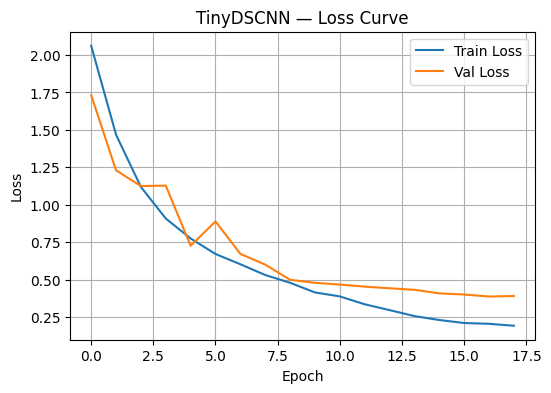

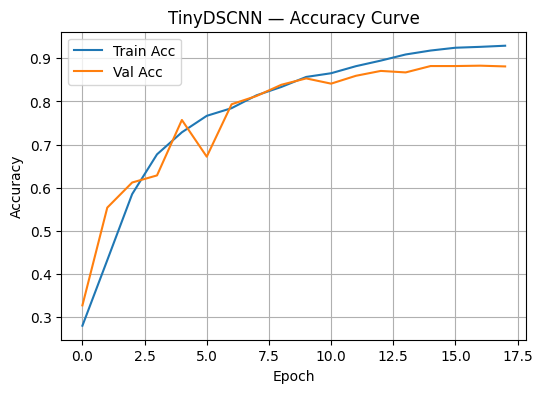

In [34]:
plot_loss(history_tiny, "TinyDSCNN — Loss Curve")
plot_accuracy(history_tiny, "TinyDSCNN — Accuracy Curve")


Test Top-1 Acc: 0.8934
Test Top-2 Acc: 0.9610

Classification report:
                 precision    recall  f1-score   support

          altar      0.905     0.887     0.896        97
           apse      0.714     0.818     0.763        55
     bell_tower      0.843     0.789     0.815       123
         column      0.921     0.873     0.896       213
    dome(inner)      0.924     0.924     0.924        66
    dome(outer)      0.924     0.924     0.924       132
flying_buttress      0.745     0.872     0.804        47
       gargoyle      0.928     0.928     0.928       180
  stained_glass      0.942     0.983     0.962       115
          vault      0.897     0.897     0.897       126

       accuracy                          0.893      1154
      macro avg      0.874     0.889     0.881      1154
   weighted avg      0.895     0.893     0.894      1154



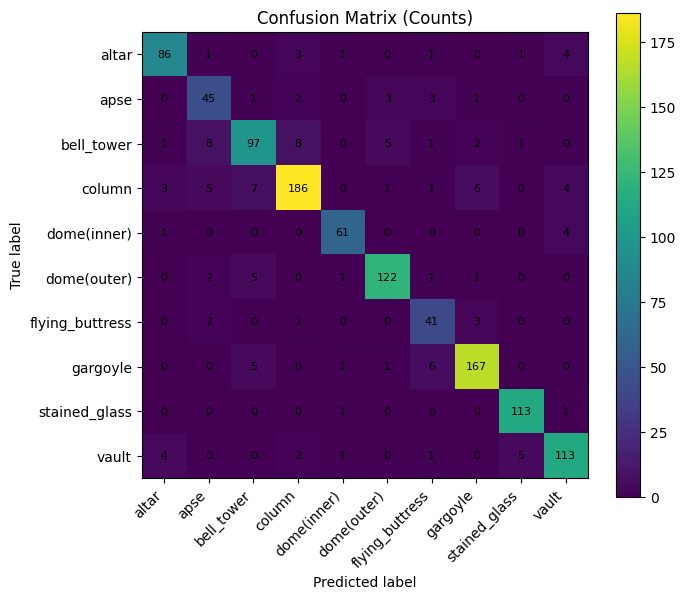

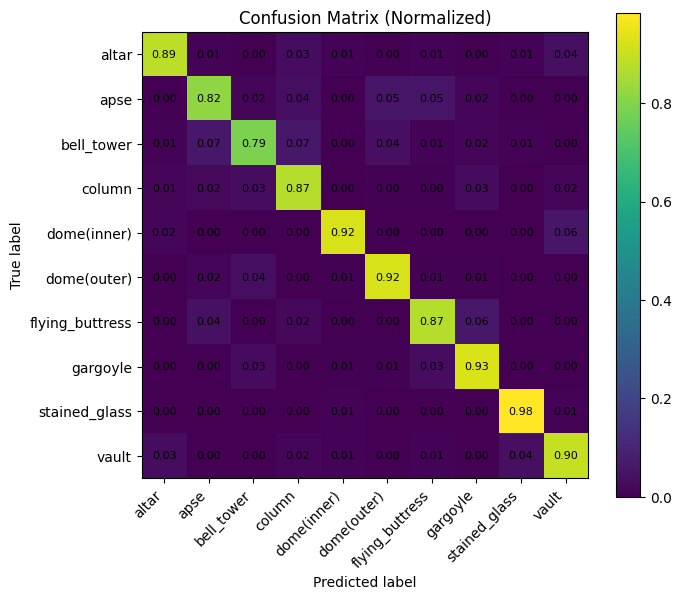

In [35]:

@torch.no_grad()
def predict_all(model, loader, device):
    model.eval()
    all_logits, all_targets = [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        all_logits.append(logits.cpu())
        all_targets.append(y)
    return torch.cat(all_logits), torch.cat(all_targets)


logits_test, y_test_tensor = predict_all(model, test_loader, device)
y_prob = torch.softmax(logits_test, dim=1).numpy()
y_pred = y_prob.argmax(axis=1)
y_true = y_test_tensor.numpy()

acc = accuracy_score(y_true, y_pred)
top2 = top_k_accuracy_score(y_true, y_prob, k=2)
print(f"Test Top-1 Acc: {acc:.4f}")
print(f"Test Top-2 Acc: {top2:.4f}")

target_names = ds.classes
print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=target_names, digits=3))

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

def plot_cm(cm, labels, title):
    plt.figure(figsize=(7,6))
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=45, ha="right")
    plt.yticks(tick_marks, labels)
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm[i, j]
            plt.text(j, i, f"{val:.2f}" if "Normalized" in title else str(val),
                     ha='center', va='center', fontsize=8)
    plt.show()

plot_cm(cm, target_names, "Confusion Matrix (Counts)")
plot_cm(cm_norm, target_names, "Confusion Matrix (Normalized)")


# 2: Resnet18 (scratch)

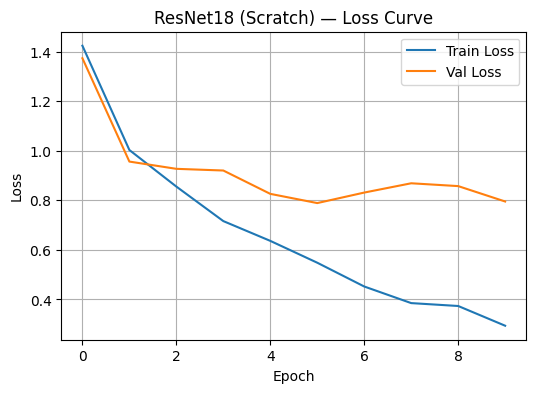

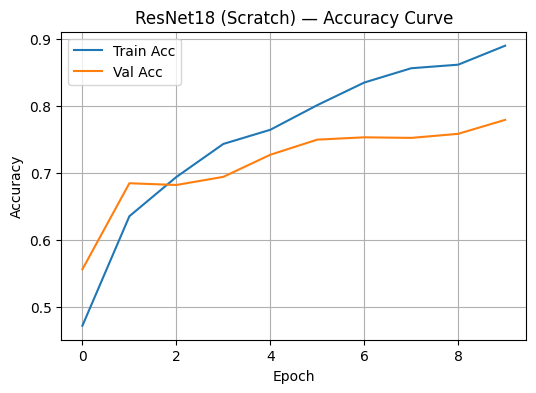

In [36]:
#Pre_trained model

plot_loss(history_rs, "ResNet18 (Scratch) — Loss Curve")
plot_accuracy(history_rs, "ResNet18 (Scratch) — Accuracy Curve")


[ResNet scratch] Test Top-1 Acc: 0.7756
[ResNet scratch] Test Top-2 Acc: 0.9090

[ResNet scratch] Classification report:
                 precision    recall  f1-score   support

          altar      0.726     0.794     0.759        97
           apse      0.564     0.800     0.662        55
     bell_tower      0.741     0.650     0.693       123
         column      0.798     0.817     0.807       213
    dome(inner)      0.786     0.833     0.809        66
    dome(outer)      0.815     0.803     0.809       132
flying_buttress      0.500     0.574     0.535        47
       gargoyle      0.819     0.806     0.812       180
  stained_glass      0.969     0.817     0.887       115
          vault      0.802     0.738     0.769       126

       accuracy                          0.776      1154
      macro avg      0.752     0.763     0.754      1154
   weighted avg      0.785     0.776     0.778      1154



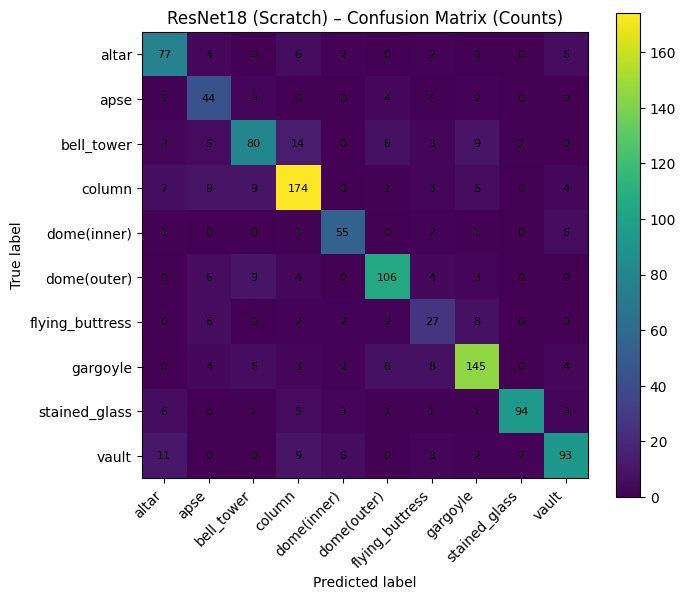

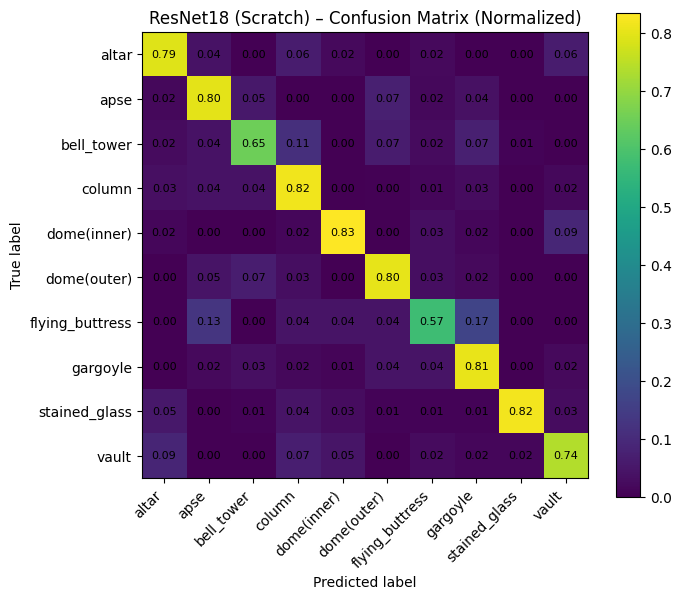

In [37]:
logits_test_rs, y_test_rs = predict_all(resnet_scratch, test_loader, device)
y_prob_rs = torch.softmax(logits_test_rs, dim=1).numpy()
y_pred_rs = y_prob_rs.argmax(axis=1)
y_true_rs = y_test_rs.numpy()

acc_rs = accuracy_score(y_true_rs, y_pred_rs)
top2_rs = top_k_accuracy_score(y_true_rs, y_prob_rs, k=2)
print(f"[ResNet scratch] Test Top-1 Acc: {acc_rs:.4f}")
print(f"[ResNet scratch] Test Top-2 Acc: {top2_rs:.4f}")
cm_rs = confusion_matrix(y_true_rs, y_pred_rs)
cm_rs_norm = cm_rs / cm_rs.sum(axis=1, keepdims=True)

print("\n[ResNet scratch] Classification report:")
print(classification_report(y_true_rs, y_pred_rs, target_names=ds.classes, digits=3))
plot_cm(cm_rs, ds.classes, "ResNet18 (Scratch) – Confusion Matrix (Counts)")
plot_cm(cm_rs_norm, ds.classes, "ResNet18 (Scratch) – Confusion Matrix (Normalized)")


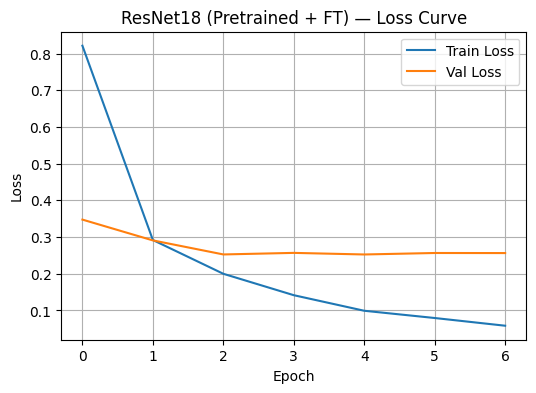

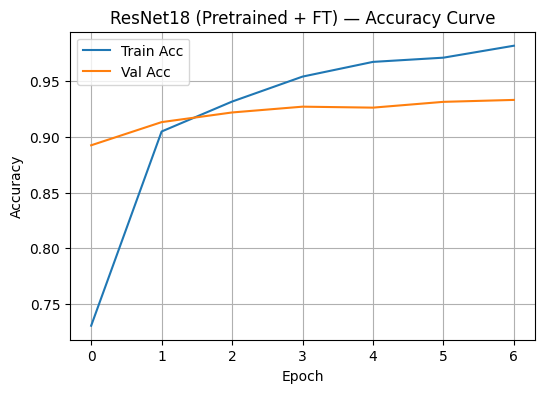

In [38]:
#Resnet FT
plot_loss(history_rft, "ResNet18 (Pretrained + FT) — Loss Curve")
plot_accuracy(history_rft, "ResNet18 (Pretrained + FT) — Accuracy Curve")


[ResNet FT] Test Top-1 Acc: 0.9177
[ResNet FT] Test Top-2 Acc: 0.9766

[ResNet FT] Classification report:
                 precision    recall  f1-score   support

          altar      0.909     0.928     0.918        97
           apse      0.730     0.836     0.780        55
     bell_tower      0.890     0.854     0.871       123
         column      0.947     0.920     0.933       213
    dome(inner)      0.930     1.000     0.964        66
    dome(outer)      0.883     0.917     0.900       132
flying_buttress      0.841     0.787     0.813        47
       gargoyle      0.949     0.939     0.944       180
  stained_glass      0.991     0.965     0.978       115
          vault      0.944     0.937     0.940       126

       accuracy                          0.918      1154
      macro avg      0.901     0.908     0.904      1154
   weighted avg      0.919     0.918     0.918      1154



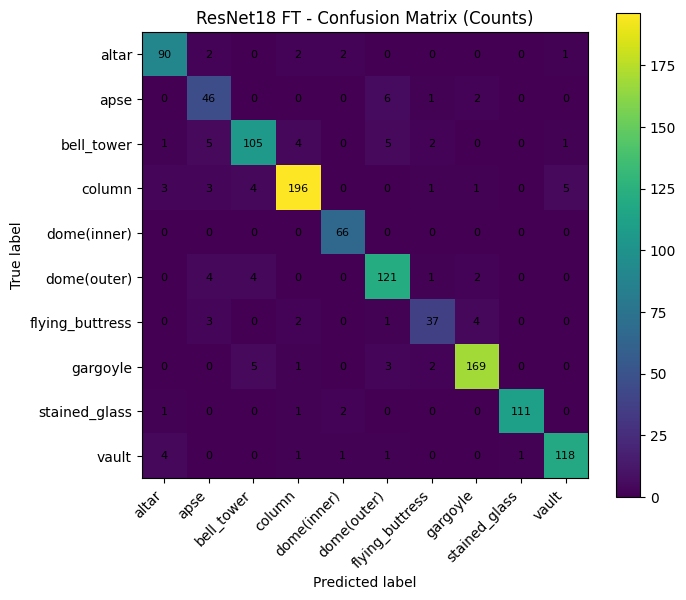

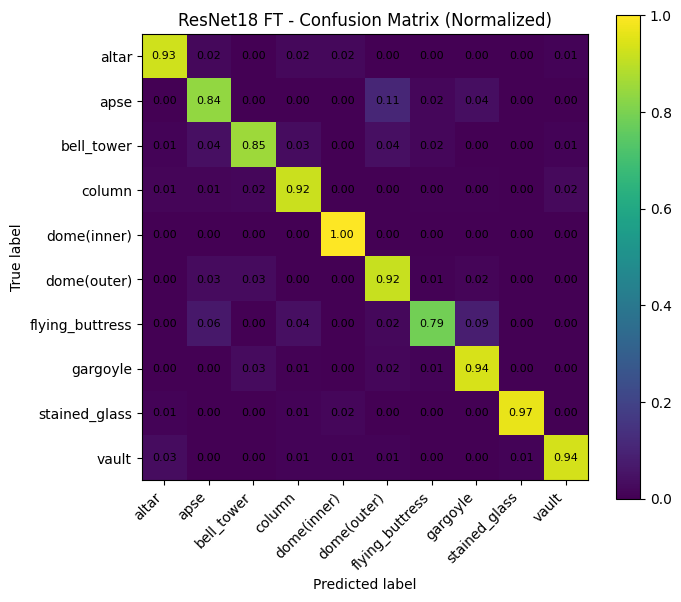

In [39]:
# Predictions and metrics for ResNet18 fine tuned
logits_test_rft, y_test_rft = predict_all(resnet_ft, test_loader, device)
y_prob_rft = torch.softmax(logits_test_rft, dim=1).numpy()
y_pred_rft = y_prob_rft.argmax(axis=1)
y_true_rft = y_test_rft.numpy()


acc_rft = accuracy_score(y_true_rft, y_pred_rft)
top2_rft = top_k_accuracy_score(y_true_rft, y_prob_rft, k=2)
print(f"[ResNet FT] Test Top-1 Acc: {acc_rft:.4f}")
print(f"[ResNet FT] Test Top-2 Acc: {top2_rft:.4f}")
cm_rft = confusion_matrix(y_true_rft, y_pred_rft)
cm_rft_norm = cm_rft / cm_rft.sum(axis=1, keepdims=True)


print("\n[ResNet FT] Classification report:")
print(classification_report(y_true_rft, y_pred_rft, target_names=ds.classes, digits=3))
plot_cm(cm_rft, ds.classes, "ResNet18 FT - Confusion Matrix (Counts)")
plot_cm(cm_rft_norm, ds.classes, "ResNet18 FT - Confusion Matrix (Normalized)")


In [40]:
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

tiny_total, tiny_trainable = count_params(model)
rs_total, rs_trainable = count_params(resnet_scratch)
rft_total, rft_trainable = count_params(resnet_ft)

print(f"TinyDSCNN - total: {tiny_total/1e6:.3f}M, trainable: {tiny_trainable/1e6:.3f}M")
print(f"ResNet18 scratch - total: {rs_total/1e6:.3f}M, trainable: {rs_trainable/1e6:.3f}M")
print(f"ResNet18 FT - total: {rft_total/1e6:.3f}M, trainable: {rft_trainable/1e6:.3f}M")


TinyDSCNN - total: 0.150M, trainable: 0.150M
ResNet18 scratch - total: 11.182M, trainable: 11.182M
ResNet18 FT - total: 11.182M, trainable: 11.182M


In [41]:

acc_tiny = acc
top2_tiny = top2

def best_epoch(history):
    """Return epoch index (1-based) where val_loss is minimal."""
    return int(np.argmin(history["val_loss"]) + 1)

results = [
    {
        "Model": "TinyDSCNN",
        "Type": "Custom CNN",
        "Top1_Acc": float(acc_tiny),
        "Top2_Acc": float(top2_tiny),
        "Epochs_Run": len(history_tiny["train_loss"]),
        "Best_Epoch": best_epoch(history_tiny),
        "Params_M": tiny_total / 1e6,
        "Trainable_M": tiny_trainable / 1e6,
    },
    {
        "Model": "ResNet18 (Scratch)",
        "Type": "Existing CNN – scratch",
        "Top1_Acc": float(acc_rs),
        "Top2_Acc": float(top2_rs),
        "Epochs_Run": len(history_rs["train_loss"]),
        "Best_Epoch": best_epoch(history_rs),
        "Params_M": rs_total / 1e6,
        "Trainable_M": rs_trainable / 1e6,
    },
    {
        "Model": "ResNet18 (Pretrained + FT)",
        "Type": "Existing CNN – fine-tuned",
        "Top1_Acc": float(acc_rft),
        "Top2_Acc": float(top2_rft),
        "Epochs_Run": len(history_rft["train_loss"]),
        "Best_Epoch": best_epoch(history_rft),
        "Params_M": rft_total / 1e6,
        "Trainable_M": rft_trainable / 1e6,
    },
]

df = pd.DataFrame(results)

# Rank by Top-1 accuracy
df = df.sort_values("Top1_Acc", ascending=False).reset_index(drop=True)
df["Rank"] = df.index + 1

cols = [
    "Rank",
    "Model",
    "Type",
    "Top1_Acc",
    "Top2_Acc",
    "Epochs_Run",
    "Best_Epoch",
    "Params_M",
    "Trainable_M",
]

print("=== Model comparison scoreboard ===")
display(df[cols])

best = df.iloc[0]
print(f"\nBest overall model: #{best.Rank} – {best.Model}")
print(
    f"Top-1 Acc: {best.Top1_Acc:.4f}, "
    f"Top-2 Acc: {best.Top2_Acc:.4f}, "
    f"Params: {best.Params_M:.3f}M (trainable {best.Trainable_M:.3f}M), "
    f"trained for {int(best.Epochs_Run)} epochs (best epoch {int(best.Best_Epoch)})"
)


=== Model comparison scoreboard ===


,Rank,Model,Type,Top1_Acc,Top2_Acc,Epochs_Run,Best_Epoch,Params_M,Trainable_M
0,1,ResNet18 (Pretrained + FT),Existing CNN – fine-tuned,0.917678,0.976603,7,5,11.181642,11.181642
1,2,TinyDSCNN,Custom CNN,0.893414,0.961005,18,17,0.150242,0.150242
2,3,ResNet18 (Scratch),Existing CNN – scratch,0.775563,0.909012,10,6,11.181642,11.181642



Best overall model: #1 – ResNet18 (Pretrained + FT)
Top-1 Acc: 0.9177, Top-2 Acc: 0.9766, Params: 11.182M (trainable 11.182M), trained for 7 epochs (best epoch 5)
